In [2]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc,
)
import warnings

warnings.filterwarnings("ignore")


In [3]:
## 1. Load và khám phá dữ liệu


In [4]:
# Load dữ liệu
df = pd.read_csv("../data/Customer_Behaviour.csv")

# Hiển thị thông tin cơ bản
print("Kích thước dữ liệu:", df.shape)
print("\n5 dòng đầu tiên:")
print(df.head())
print("\nThông tin về dữ liệu:")
print(df.info())
print("\nThống kê mô tả:")
print(df.describe())


Kích thước dữ liệu: (400, 5)

5 dòng đầu tiên:
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0

Thông tin về dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None

Thống kê mô tả:
            User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       400.000000  400.00000

In [5]:
# Kiểm tra giá trị null và phân bố của biến target
print("Giá trị null trong dữ liệu:")
print(df.isnull().sum())
print("\nPhân bố của biến Purchased:")
print(df["Purchased"].value_counts())
print("\nTỷ lệ phần trăm:")
print(df["Purchased"].value_counts(normalize=True) * 100)


Giá trị null trong dữ liệu:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Phân bố của biến Purchased:
Purchased
0    257
1    143
Name: count, dtype: int64

Tỷ lệ phần trăm:
Purchased
0    64.25
1    35.75
Name: proportion, dtype: float64


## 2. Trực quan hóa dữ liệu


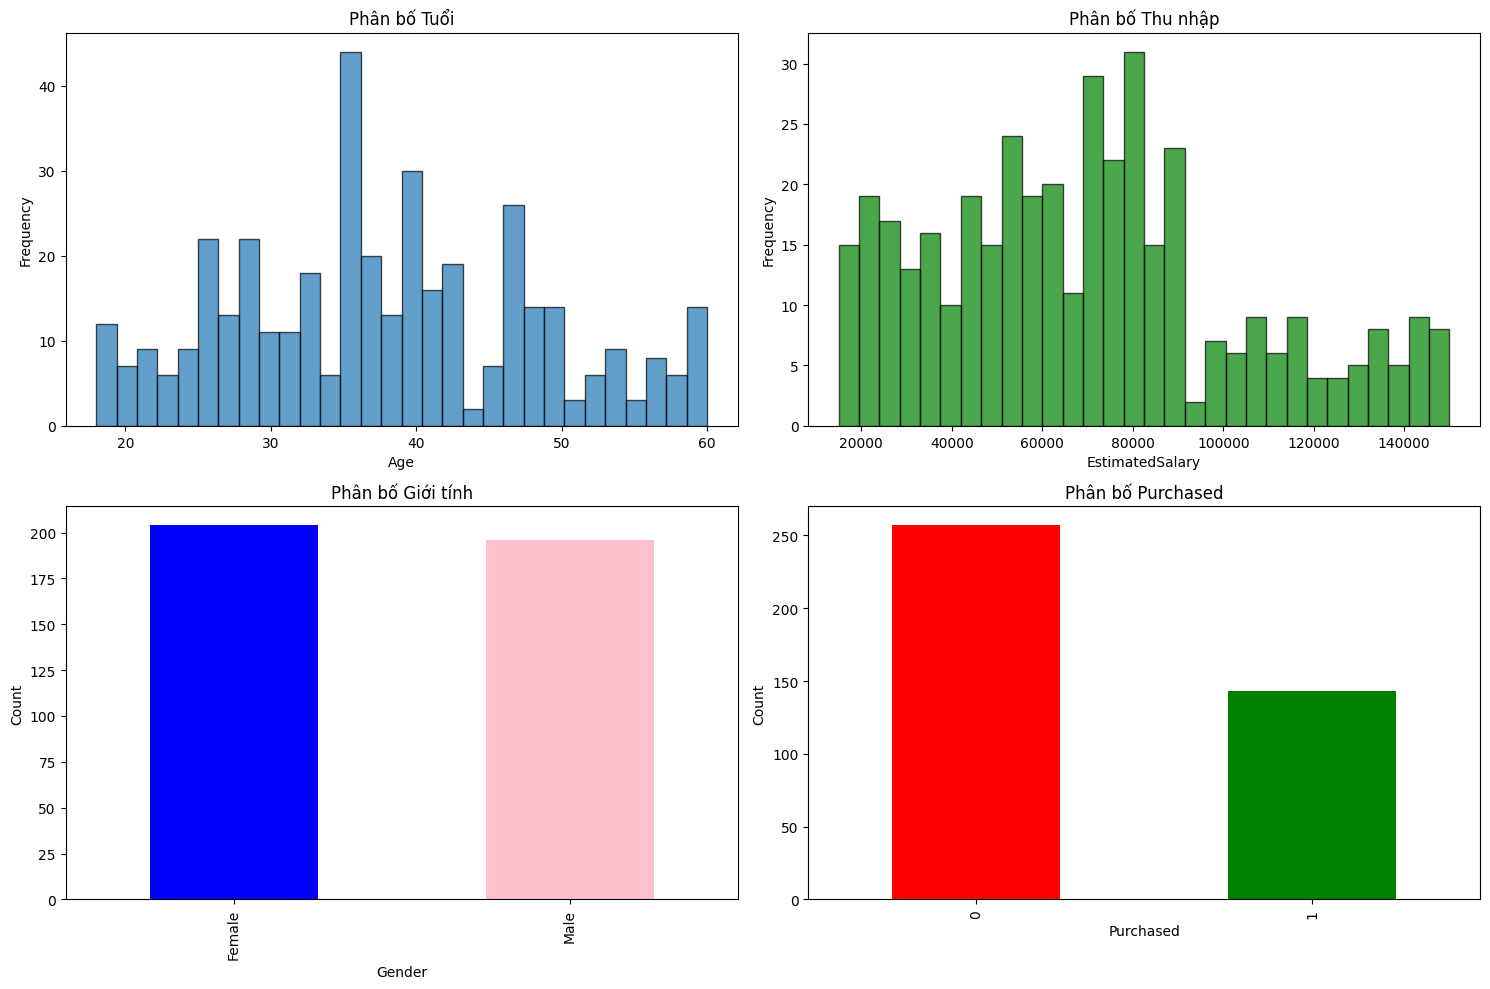

In [6]:
# Phân bố của các biến
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age distribution
axes[0, 0].hist(df["Age"], bins=30, edgecolor="black", alpha=0.7)
axes[0, 0].set_title("Phân bố Tuổi")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Frequency")

# EstimatedSalary distribution
axes[0, 1].hist(
    df["EstimatedSalary"], bins=30, edgecolor="black", alpha=0.7, color="green"
)
axes[0, 1].set_title("Phân bố Thu nhập")
axes[0, 1].set_xlabel("EstimatedSalary")
axes[0, 1].set_ylabel("Frequency")

# Gender distribution
df["Gender"].value_counts().plot(kind="bar", ax=axes[1, 0], color=["blue", "pink"])
axes[1, 0].set_title("Phân bố Giới tính")
axes[1, 0].set_xlabel("Gender")
axes[1, 0].set_ylabel("Count")

# Purchased distribution
df["Purchased"].value_counts().plot(kind="bar", ax=axes[1, 1], color=["red", "green"])
axes[1, 1].set_title("Phân bố Purchased")
axes[1, 1].set_xlabel("Purchased")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()


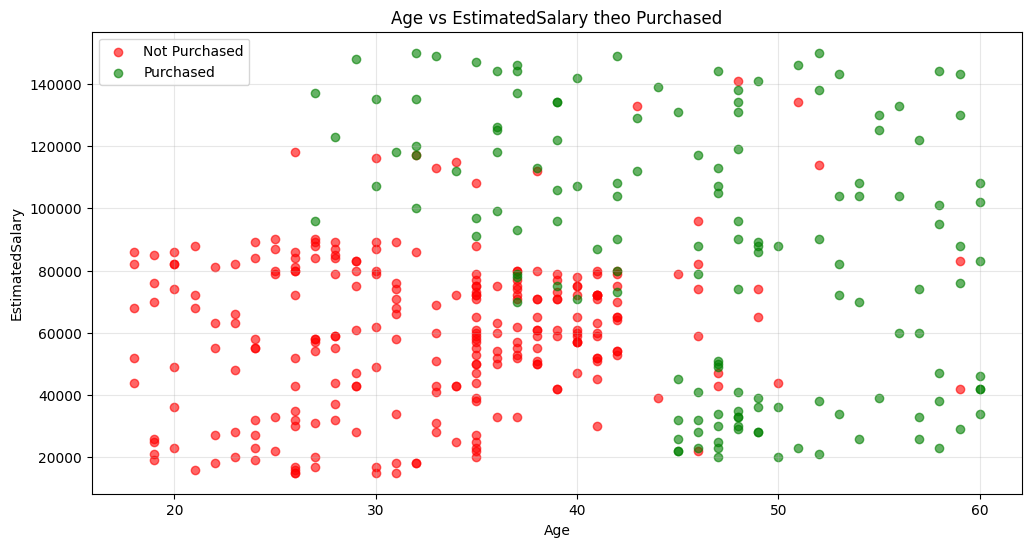

In [7]:
# Scatter plot: Age vs EstimatedSalary theo Purchased
plt.figure(figsize=(12, 6))
colors = ["red", "green"]
labels = ["Not Purchased", "Purchased"]

for i in [0, 1]:
    plt.scatter(
        df[df["Purchased"] == i]["Age"],
        df[df["Purchased"] == i]["EstimatedSalary"],
        c=colors[i],
        label=labels[i],
        alpha=0.6,
    )

plt.xlabel("Age")
plt.ylabel("EstimatedSalary")
plt.title("Age vs EstimatedSalary theo Purchased")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 3. Tiền xử lý dữ liệu


In [8]:
# Tạo bản sao để xử lý
df_processed = df.copy()

# Loại bỏ cột User ID (không cần thiết cho mô hình)
df_processed = df_processed.drop("User ID", axis=1)

# Mã hóa biến Gender (Male = 1, Female = 0)
df_processed["Gender"] = df_processed["Gender"].map({"Male": 1, "Female": 0})

print("Dữ liệu sau khi xử lý:")
print(df_processed.head())
print("\nKiểm tra kiểu dữ liệu:")
print(df_processed.dtypes)


Dữ liệu sau khi xử lý:
   Gender  Age  EstimatedSalary  Purchased
0       1   19            19000          0
1       1   35            20000          0
2       0   26            43000          0
3       0   27            57000          0
4       1   19            76000          0

Kiểm tra kiểu dữ liệu:
Gender             int64
Age                int64
EstimatedSalary    int64
Purchased          int64
dtype: object


In [9]:
# Tách features và target
X = df_processed.drop("Purchased", axis=1)
y = df_processed["Purchased"]

print("Shape của X:", X.shape)
print("Shape của y:", y.shape)
print("\nCác features:")
print(X.columns.tolist())


Shape của X: (400, 3)
Shape của y: (400,)

Các features:
['Gender', 'Age', 'EstimatedSalary']


In [10]:
# Chia dữ liệu thành tập train và test (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Kích thước tập train:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print("\nKích thước tập test:")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
print("\nPhân bố của y_train:")
print(y_train.value_counts())
print("\nPhân bố của y_test:")
print(y_test.value_counts())


Kích thước tập train:
X_train: (320, 3), y_train: (320,)

Kích thước tập test:
X_test: (80, 3), y_test: (80,)

Phân bố của y_train:
Purchased
0    206
1    114
Name: count, dtype: int64

Phân bố của y_test:
Purchased
0    51
1    29
Name: count, dtype: int64


In [11]:
# Chuẩn hóa dữ liệu (Feature Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dữ liệu sau khi chuẩn hóa:")
print("X_train_scaled mean:", X_train_scaled.mean(axis=0))
print("X_train_scaled std:", X_train_scaled.std(axis=0))
print("\nVí dụ 5 mẫu đầu tiên:")
print(pd.DataFrame(X_train_scaled[:5], columns=X.columns))


Dữ liệu sau khi chuẩn hóa:
X_train_scaled mean: [ 7.21644966e-17  8.32667268e-18 -8.32667268e-18]
X_train_scaled std: [1. 1. 1.]

Ví dụ 5 mẫu đầu tiên:
     Gender       Age  EstimatedSalary
0  1.084837 -1.234462        -0.367992
1 -0.921798 -0.577646        -1.058314
2 -0.921798  0.079170         0.264803
3 -0.921798  1.955786        -1.374712
4 -0.921798  0.360662        -0.310465


## 4. Xây dựng mô hình Naive Bayes


In [12]:
# Khởi tạo và huấn luyện mô hình Gaussian Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

print("Mô hình Naive Bayes đã được huấn luyện!")
print("Các tham số của mô hình:")
print(f"Classes: {nb_model.classes_}")
print(f"Class prior probabilities: {nb_model.class_prior_}")


Mô hình Naive Bayes đã được huấn luyện!
Các tham số của mô hình:
Classes: [0 1]
Class prior probabilities: [0.64375 0.35625]


## 5. Dự đoán và đánh giá mô hình


In [13]:
# Dự đoán trên tập train và test
y_train_pred = nb_model.predict(X_train_scaled)
y_test_pred = nb_model.predict(X_test_scaled)

# Tính accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=== KẾT QUẢ ĐÁNH GIÁ ===")
print(f"\nAccuracy trên tập Train: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Accuracy trên tập Test: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


=== KẾT QUẢ ĐÁNH GIÁ ===

Accuracy trên tập Train: 0.8906 (89.06%)
Accuracy trên tập Test: 0.8750 (87.50%)


In [14]:
# Classification Report
print("\n=== CLASSIFICATION REPORT (Test Set) ===")
print(
    classification_report(
        y_test, y_test_pred, target_names=["Not Purchased", "Purchased"]
    )
)



=== CLASSIFICATION REPORT (Test Set) ===
               precision    recall  f1-score   support

Not Purchased       0.89      0.92      0.90        51
    Purchased       0.85      0.79      0.82        29

     accuracy                           0.88        80
    macro avg       0.87      0.86      0.86        80
 weighted avg       0.87      0.88      0.87        80



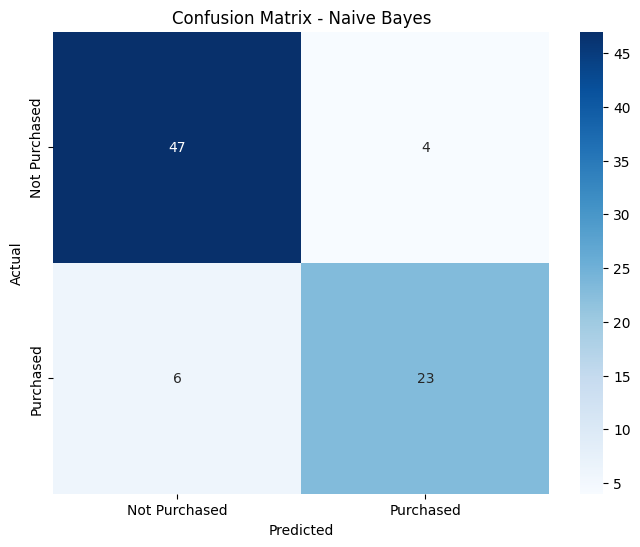


Confusion Matrix:
[[47  4]
 [ 6 23]]

True Negatives: 47
False Positives: 4
False Negatives: 6
True Positives: 23


In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Purchased", "Purchased"],
    yticklabels=["Not Purchased", "Purchased"],
)
plt.title("Confusion Matrix - Naive Bayes")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")


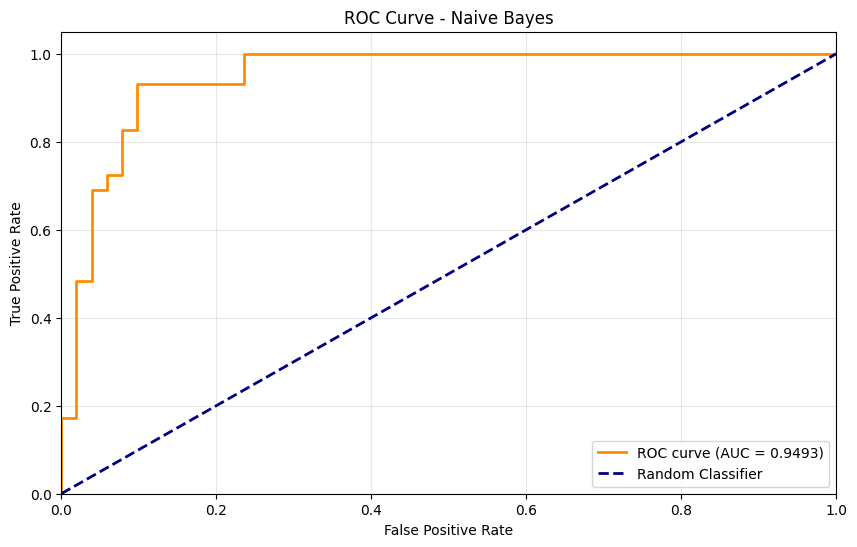


AUC Score: 0.9493


In [16]:
# ROC Curve và AUC Score
y_test_proba = nb_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Classifier")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"\nAUC Score: {roc_auc:.4f}")


## 6. Dự đoán với dữ liệu mới


In [17]:
# Ví dụ dự đoán với khách hàng mới
new_customers = pd.DataFrame(
    {
        "Gender": [1, 0, 1],  # Male, Female, Male
        "Age": [25, 45, 35],
        "EstimatedSalary": [50000, 120000, 75000],
    }
)

print("Thông tin khách hàng mới:")
print(new_customers)

# Chuẩn hóa dữ liệu mới
new_customers_scaled = scaler.transform(new_customers)

# Dự đoán
predictions = nb_model.predict(new_customers_scaled)
probabilities = nb_model.predict_proba(new_customers_scaled)

print("\n=== KẾT QUẢ DỰ ĐOÁN ===")
for i in range(len(new_customers)):
    gender = "Male" if new_customers.iloc[i]["Gender"] == 1 else "Female"
    age = new_customers.iloc[i]["Age"]
    salary = new_customers.iloc[i]["EstimatedSalary"]
    prediction = "Purchased" if predictions[i] == 1 else "Not Purchased"
    prob_not_purchase = probabilities[i][0] * 100
    prob_purchase = probabilities[i][1] * 100

    print(f"\nKhách hàng {i+1}: {gender}, {age} tuổi, Thu nhập ${salary}")
    print(f"  Dự đoán: {prediction}")
    print(f"  Xác suất Not Purchased: {prob_not_purchase:.2f}%")
    print(f"  Xác suất Purchased: {prob_purchase:.2f}%")


Thông tin khách hàng mới:
   Gender  Age  EstimatedSalary
0       1   25            50000
1       0   45           120000
2       1   35            75000

=== KẾT QUẢ DỰ ĐOÁN ===

Khách hàng 1: Male, 25 tuổi, Thu nhập $50000
  Dự đoán: Not Purchased
  Xác suất Not Purchased: 98.28%
  Xác suất Purchased: 1.72%

Khách hàng 2: Female, 45 tuổi, Thu nhập $120000
  Dự đoán: Purchased
  Xác suất Not Purchased: 5.96%
  Xác suất Purchased: 94.04%

Khách hàng 3: Male, 35 tuổi, Thu nhập $75000
  Dự đoán: Not Purchased
  Xác suất Not Purchased: 86.71%
  Xác suất Purchased: 13.29%


## 7. Phân tích Feature Importance


=== PHÂN TÍCH FEATURE THEO CLASS ===

Class 0 (Not Purchased):
Mean values: [ 0.02307386 -0.46012976 -0.30376301]
Variance values: [1.00322954 0.57350864 0.50430773]

Class 1 (Purchased):
Mean values: [-0.04169487  0.83146256  0.54890508]
Variance values: [0.99146365 0.69676672 1.42769079]


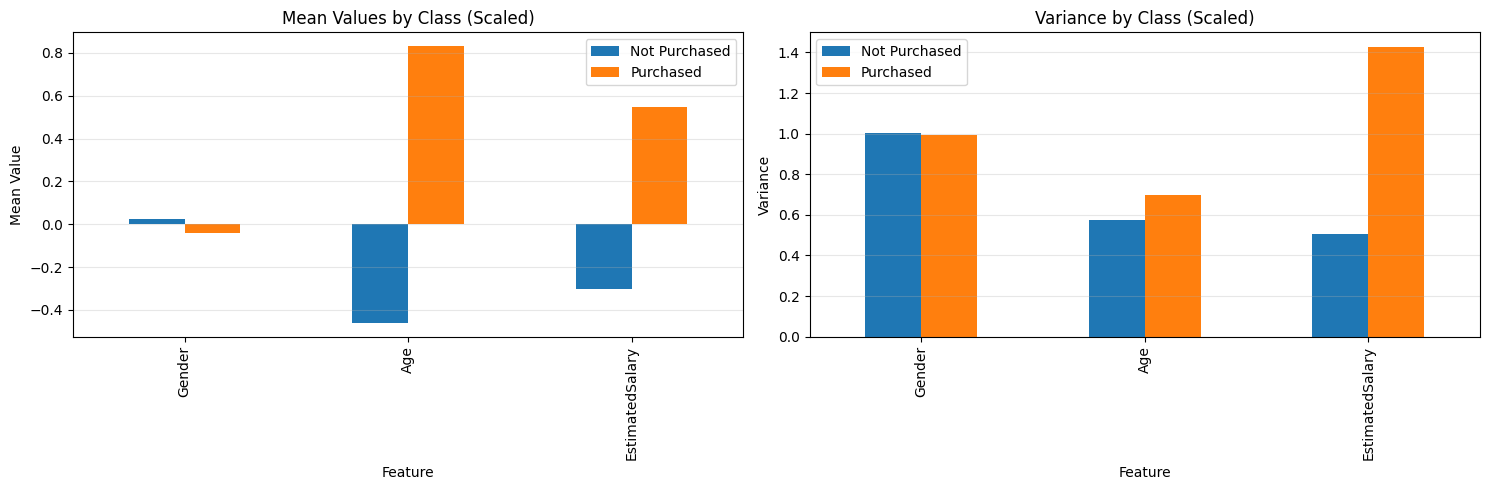

In [18]:
# Phân tích mean và variance của mỗi feature theo class
feature_names = X.columns

print("=== PHÂN TÍCH FEATURE THEO CLASS ===")
print("\nClass 0 (Not Purchased):")
print("Mean values:", nb_model.theta_[0])
print("Variance values:", nb_model.var_[0])

print("\nClass 1 (Purchased):")
print("Mean values:", nb_model.theta_[1])
print("Variance values:", nb_model.var_[1])

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Mean values
means_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Not Purchased": nb_model.theta_[0],
        "Purchased": nb_model.theta_[1],
    }
)
means_df.set_index("Feature").plot(kind="bar", ax=axes[0])
axes[0].set_title("Mean Values by Class (Scaled)")
axes[0].set_ylabel("Mean Value")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Variance values
var_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Not Purchased": nb_model.var_[0],
        "Purchased": nb_model.var_[1],
    }
)
var_df.set_index("Feature").plot(kind="bar", ax=axes[1])
axes[1].set_title("Variance by Class (Scaled)")
axes[1].set_ylabel("Variance")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Tổng kết Pipeline


In [19]:
print("=" * 60)
print("TỔNG KẾT PIPELINE MACHINE LEARNING - NAIVE BAYES")
print("=" * 60)
print(f"\n1. Dataset: Customer_Behaviour.csv")
print(f"   - Số mẫu: {len(df)}")
print(f"   - Số features: {X.shape[1]} (Gender, Age, EstimatedSalary)")
print(f"   - Biến target: Purchased (Binary: 0/1)")

print(f"\n2. Data Split:")
print(f"   - Training set: {len(X_train)} mẫu ({len(X_train)/len(df)*100:.1f}%)")
print(f"   - Test set: {len(X_test)} mẫu ({len(X_test)/len(df)*100:.1f}%)")

print(f"\n3. Preprocessing:")
print(f"   - Encoding: Gender (Male=1, Female=0)")
print(f"   - Scaling: StandardScaler")

print(f"\n4. Model: Gaussian Naive Bayes")
print(f"   - Algorithm: GaussianNB")

print(f"\n5. Performance:")
print(f"   - Train Accuracy: {train_accuracy:.4f}")
print(f"   - Test Accuracy: {test_accuracy:.4f}")
print(f"   - AUC Score: {roc_auc:.4f}")

print(f"\n6. Kết luận:")
if test_accuracy > 0.85:
    print(f"   ✓ Mô hình hoạt động TỐT với accuracy {test_accuracy*100:.2f}%")
elif test_accuracy > 0.75:
    print(f"   ✓ Mô hình hoạt động KHÁ với accuracy {test_accuracy*100:.2f}%")
else:
    print(f"   ⚠ Mô hình cần cải thiện (accuracy {test_accuracy*100:.2f}%)")

print("\n" + "=" * 60)


TỔNG KẾT PIPELINE MACHINE LEARNING - NAIVE BAYES

1. Dataset: Customer_Behaviour.csv
   - Số mẫu: 400
   - Số features: 3 (Gender, Age, EstimatedSalary)
   - Biến target: Purchased (Binary: 0/1)

2. Data Split:
   - Training set: 320 mẫu (80.0%)
   - Test set: 80 mẫu (20.0%)

3. Preprocessing:
   - Encoding: Gender (Male=1, Female=0)
   - Scaling: StandardScaler

4. Model: Gaussian Naive Bayes
   - Algorithm: GaussianNB

5. Performance:
   - Train Accuracy: 0.8906
   - Test Accuracy: 0.8750
   - AUC Score: 0.9493

6. Kết luận:
   ✓ Mô hình hoạt động TỐT với accuracy 87.50%

